# Introduction to text embeddings on S&P 500 news

objectives# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Retrieve Financial News:**
   - Use the `yfinance` library to gather news headlines for all companies in the S&P 500 index.

2. **Clean and Structure Financial Text Data:**
   - Extract and organize relevant metadata (e.g., ticker, title, summary, publication date, URL) into a structured pandas DataFrame.

3. **Generate Text Embeddings:**
   - Apply a pre-trained sentence transformer model (`all-MiniLM-L6-v2`) to convert news headlines and summaries into numerical embeddings.

4. **Apply Clustering Techniques:**
   - Use K-Means clustering to identify groups of similar news articles based on semantic content.

5. **Determine Optimal Number of Clusters:**
   - Evaluate clustering quality using silhouette scores to find the best number of clusters.

6. **Visualize High-Dimensional Embeddings:**
   - Reduce the embedding space using PCA and visualize clusters in two dimensions.

7. **Interpret Cluster Themes:**
   - Analyze representative news


## Install and Import important librairies

In [1]:
%pip install pandas
%pip install yfinance
%pip install lxml
%pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.2/470.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [2]:
from sentence_transformers import SentenceTransformer
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import pandas as pd
from sklearn.metrics import silhouette_score
import yfinance as yf

## Get the list of stocks in the S&P 500

In [3]:
# Read and print the stock tickers that make up S&P500
df_tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]

display(df_tickers.head())

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [4]:
ticker_list = df_tickers['Symbol'].tolist()

## Get the news of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the news of all 500 stocks in the index.
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

### Get the news in a dictionary

In [5]:
# Create a dictionary where the keys are the symbols (tickers) of each 500 stocks
# and the value is the output news from the yfinance library

# YOUR CODE HERE
import time
news_dict = {}
for ticker in ticker_list:
    news_dict[ticker] = yf.Ticker(ticker).news
    time.sleep(0.3)
print(len(news_dict))

503


### Structure the news into a pandas dataframe

Your final dataframe should have the following columns:
- TICKER
- TITLE (of the news)
- SUMMARY (of the news)
- PUBLICATION_DATE (of the news)
- URL (of the news)

Note: all of those fields are provided in the yfinance news component. Refer to the library documentation.

In [6]:
print(news_dict['MMM'])

[{'id': '2f475c52-e043-3340-9129-7f18b3fdb18d', 'content': {'id': '2f475c52-e043-3340-9129-7f18b3fdb18d', 'contentType': 'STORY', 'title': '3M Company (MMM): “I Was Surprised” By The Organic Growth Rate, Says Jim Cramer', 'description': '', 'summary': 'We recently published 12 Stocks Jim Cramer Talked About. 3M Company (NYSE:MMM) is one of the stocks Jim Cramer recently discussed. 3M Company (NYSE:MMM) is one of the largest industrial conglomerates in the world. Its shares have gained 16.7% year-to-date as part of a bullish run in industrial stocks that Cramer has commented on several […]', 'pubDate': '2025-07-24T09:03:00Z', 'displayTime': '2025-07-24T09:03:00Z', 'isHosted': True, 'bypassModal': False, 'previewUrl': None, 'thumbnail': {'originalUrl': 'https://media.zenfs.com/en/insidermonkey.com/093e1a4edd0e304bc17c1f522a735210', 'originalWidth': 1000, 'originalHeight': 667, 'caption': '3M Company (MMM): "I Was Surprised" By The Organic Growth Rate, Says Jim Cramer', 'resolutions': [{'

In [9]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

news_df = pd.DataFrame(columns=['TICKER', 'TITLE', 'SUMMARY', 'PUBLICATION_DATE', 'URL'])

for ticker, content in news_dict.items():
    print(f"Ticker: {ticker}")
    for article in content:
        # ttl=article['content']['title']
        # sum=article['content']['summary']
        # pub_date=article['content']['pubDate']
        try:
      #if statement in case its empty values
          if article['content']['title'] is not None:
              print(f"Title: {article['content']['title']}")
              ttl=article['content']['title']

          if article['content']['summary'] is not None:
              print(f"Summary: {article['content']['summary']}")
              sum=article['content']['summary']

          if article['content']['pubDate'] is not None:
              print(f"Publication Date: {article['content']['pubDate']}")
              pub_date=article['content']['pubDate']

              if article['content']['previewUrl'] is not None:
                  print(f"URL previewUrl: {article['content']['previewUrl']}")
                  url=article['content']['previewUrl']
              else:
                if article['content']['thumbnail']['originalUrl'] is not None :
                  print(f"URL originalUrl: {article['content']['thumbnail']['originalUrl']}")
                  url=article['content']['thumbnail']['originalUrl']
                else:
                  if article['content']['canonicalUrl']['url'] is not None:
                    print(f"URL canonicalUrl: {article['content']['canonicalUrl']['url']}")
                    url=article['content']['canonicalUrl']['url']
        except:
            print(f"URL: NONE")
            url='NONE'
            ttl='NONE'
            sum='NONE'
            pub_date='NONE'

        print()

        news_df = pd.concat([news_df, pd.DataFrame({'TICKER': [ticker], 'TITLE': [ttl], 'SUMMARY': [sum], 'PUBLICATION_DATE': [pub_date], 'URL': [url]})])

    print("-------------------------------------------------------------------")

news_df.reset_index()

len(news_df)


Se truncaron las últimas líneas 5000 del resultado de transmisión.
Title: SBA Communications Stock: Is SBAC Outperforming the Real Estate Sector?
Summary: SBA Communications has notably outperformed the real estate sector over the past year, and analysts remain somewhat optimistic about the stock’s long-term prospects.
Publication Date: 2025-06-18T09:35:03Z
URL originalUrl: https://media.zenfs.com/en/barchart_com_477/a4f682c0f6fb9771ac45877d7037d7cd

Title: Millicom reports partial closing of infrastructure deal with SBA Communications
Summary: Millicom International (TIGO) announced the partial closing of its previously disclosed transaction with SBA Communications Corporation (SBAC), through the sale of LATI International S.A., the Luxembourg-based holding company for Millicom’s mobile passive infrastructure assets in Central America. To date, completed closings have generated approximately $600 million in proceeds, with the remainder of the approximately $975 million transaction exp

5010

## Exploring text embeddings

- Use the open-source model: 'sentence-transformers/all-MiniLM-L6-v2' to create embeddings on the news title and summary
- Add a column to your news dataframe called EMBEDDED_TEXT using ONLY the TITLE of the news
- Add a column to your news dataframe called EMBEDDINGS, which contains the embedding of EMBEDDED_TEXT


In [10]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

model=SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [11]:
sentences= news_df['TITLE'].tolist()
sentences

['3M Company (MMM): “I Was Surprised” By The Organic Growth Rate, Says Jim Cramer',
 'Zacks Industry Outlook Highlights Honeywell, 3M, Carlisle Companies and Federal Signal',
 'Stock Market News for Jul 21, 2025',
 '3M Co (MMM) Q2 2025 Earnings Call Highlights: Strong EPS Growth Amidst Global Challenges',
 'MMM Q1 Deep Dive: Tariffs Loom Over Stable Operations and Product Launch Momentum',
 'Dow Falls as Trump Reportedly Seeks Higher EU Tariffs; Nasdaq Clinches New High',
 '3M Gives Investors a ‘Beat and Raise.’ The Stock Is Rising.',
 'Equities Fall Intraday as Trump Reportedly Pushes for Higher Tariffs on EU',
 'NONE',
 '3M (MMM) Stock Trades Down, Here Is Why',
 "Here's Why A.O. Smith (AOS) is a Strong Value Stock",
 'Earnings Beat: A. O. Smith Corporation Just Beat Analyst Forecasts, And Analysts Have Been Updating Their Models',
 'NONE',
 'A.O. Smith Corp (AOS) Q2 2025 Earnings Call Highlights: Navigating Challenges with Strategic ...',
 'AOS Q2 Deep Dive: New CEO Charts Path Amid

In [12]:
len(sentences)

5010

In [13]:
sentence_embd= model.encode(sentences)
sentence_embd

array([[ 0.00645542, -0.10904754, -0.07995971, ..., -0.12938619,
         0.06375785,  0.00975934],
       [-0.0216293 , -0.07978325, -0.02543494, ..., -0.03385701,
         0.00668812, -0.0099588 ],
       [-0.03746959, -0.04381374,  0.02352595, ..., -0.10105158,
        -0.03839877,  0.06310392],
       ...,
       [-0.07060869,  0.06210669,  0.03203607, ..., -0.08665355,
        -0.0370895 ,  0.09530663],
       [-0.03358546,  0.02143671,  0.03210171, ..., -0.15456805,
         0.017412  ,  0.02907416],
       [ 0.01717706, -0.01058648, -0.0419318 , ..., -0.13459921,
         0.02495301,  0.09797999]], dtype=float32)

In [14]:
news_df['EMBEDDED_TEXT']=news_df['TITLE']
news_df.reset_index( inplace=True)

In [15]:
len(sentence_embd)

5010

In [16]:
sentence_embd.shape

(5010, 384)

In [17]:
news_df['Embeddings'] = sentence_embd.tolist()
news_df=news_df[['TICKER', 'TITLE', 'SUMMARY', 'PUBLICATION_DATE', 'URL','EMBEDDED_TEXT','Embeddings']]
news_df.head()

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24T09:03:00Z,https://media.zenfs.com/en/insidermonkey.com/0...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455422844737768, -0.1090475395321846, -0..."
1,MMM,"Zacks Industry Outlook Highlights Honeywell, 3...","HON, MMM, CSL, and FSS are well-positioned to ...",2025-07-21T09:45:00Z,https://media.zenfs.com/en/zacks.com/35bb427ea...,"Zacks Industry Outlook Highlights Honeywell, 3...","[-0.021629296243190765, -0.07978324592113495, ..."
2,MMM,"Stock Market News for Jul 21, 2025",U.S. stock markets closed mostly lower n Frida...,2025-07-21T08:22:00Z,https://media.zenfs.com/en/zacks.com/3c91a0562...,"Stock Market News for Jul 21, 2025","[-0.037469588220119476, -0.043813738971948624,..."
3,MMM,3M Co (MMM) Q2 2025 Earnings Call Highlights: ...,3M Co (MMM) reports a 12% increase in adjusted...,2025-07-19T07:05:47Z,https://media.zenfs.com/en/us.finance.gurufocu...,3M Co (MMM) Q2 2025 Earnings Call Highlights: ...,"[-0.08080150932073593, -0.02980075404047966, -..."
4,MMM,MMM Q1 Deep Dive: Tariffs Loom Over Stable Ope...,Industrial conglomerate 3M (NYSE:MMM) reported...,2025-07-19T05:30:58Z,https://media.zenfs.com/en/stockstory_922/f5a4...,MMM Q1 Deep Dive: Tariffs Loom Over Stable Ope...,"[-0.019502639770507812, -0.07280389964580536, ..."


In [18]:
len(news_df)

5010

## Using K-means clustering on news embeddings
to simplify, keep only one news for each company (ticker), you should have 500 rows in your news dataframe

In [19]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS
mmm_df=news_df[news_df['TICKER']=='MMM']
mmm_df

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24T09:03:00Z,https://media.zenfs.com/en/insidermonkey.com/0...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455422844737768, -0.1090475395321846, -0..."
1,MMM,"Zacks Industry Outlook Highlights Honeywell, 3...","HON, MMM, CSL, and FSS are well-positioned to ...",2025-07-21T09:45:00Z,https://media.zenfs.com/en/zacks.com/35bb427ea...,"Zacks Industry Outlook Highlights Honeywell, 3...","[-0.021629296243190765, -0.07978324592113495, ..."
2,MMM,"Stock Market News for Jul 21, 2025",U.S. stock markets closed mostly lower n Frida...,2025-07-21T08:22:00Z,https://media.zenfs.com/en/zacks.com/3c91a0562...,"Stock Market News for Jul 21, 2025","[-0.037469588220119476, -0.043813738971948624,..."
3,MMM,3M Co (MMM) Q2 2025 Earnings Call Highlights: ...,3M Co (MMM) reports a 12% increase in adjusted...,2025-07-19T07:05:47Z,https://media.zenfs.com/en/us.finance.gurufocu...,3M Co (MMM) Q2 2025 Earnings Call Highlights: ...,"[-0.08080150932073593, -0.02980075404047966, -..."
4,MMM,MMM Q1 Deep Dive: Tariffs Loom Over Stable Ope...,Industrial conglomerate 3M (NYSE:MMM) reported...,2025-07-19T05:30:58Z,https://media.zenfs.com/en/stockstory_922/f5a4...,MMM Q1 Deep Dive: Tariffs Loom Over Stable Ope...,"[-0.019502639770507812, -0.07280389964580536, ..."
5,MMM,Dow Falls as Trump Reportedly Seeks Higher EU ...,The Dow Jones Industrial Average fell Friday f...,2025-07-18T21:11:10Z,https://media.zenfs.com/en/mt_newswires_premiu...,Dow Falls as Trump Reportedly Seeks Higher EU ...,"[0.018626129254698753, -0.0316285640001297, 0...."
6,MMM,3M Gives Investors a ‘Beat and Raise.’ The Sto...,3M traded higher initially after reporting be...,2025-07-18T20:36:00Z,https://finance.yahoo.com/m/b7e536e2-6640-3d38...,3M Gives Investors a ‘Beat and Raise.’ The Sto...,"[0.023755820468068123, -0.10996507853269577, -..."
7,MMM,Equities Fall Intraday as Trump Reportedly Pus...,US benchmark equity indexes fell intraday amid...,2025-07-18T18:36:40Z,https://media.zenfs.com/en/mt_newswires_premiu...,Equities Fall Intraday as Trump Reportedly Pus...,"[0.040155719965696335, 0.016992364078760147, 0..."
8,MMM,NONE,NONE,NONE,NONE,NONE,"[0.0024043903686106205, -0.04070057347416878, ..."
9,MMM,"3M (MMM) Stock Trades Down, Here Is Why",Shares of industrial conglomerate 3M (NYSE:MMM...,2025-07-18T16:25:52Z,https://media.zenfs.com/en/stockstory_922/f5a4...,"3M (MMM) Stock Trades Down, Here Is Why","[0.04963048920035362, -0.09073001891374588, 0...."


In [20]:
df_mmm= mmm_df.drop_duplicates(subset=['TICKER'])
df_mmm

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24T09:03:00Z,https://media.zenfs.com/en/insidermonkey.com/0...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455422844737768, -0.1090475395321846, -0..."


In [21]:
df_ticker_new= df_mmm.copy()

In [22]:
appl_df=news_df[news_df['TICKER']=='AAPL']
df_appl= appl_df.drop_duplicates(subset=['TICKER'])
df_ticker_new= pd.concat([df_ticker_new, df_appl])
df_ticker_new

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24T09:03:00Z,https://media.zenfs.com/en/insidermonkey.com/0...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455422844737768, -0.1090475395321846, -0..."
380,AAPL,"Earnings live: Microsoft, Apple, Amazon highli...","This week, 112 S&P 500 companies report Q2 res...",2025-07-28T11:43:03Z,https://s.yimg.com/os/creatr-uploaded-images/2...,"Earnings live: Microsoft, Apple, Amazon highli...","[-0.046537432819604874, -0.009206648916006088,..."


In [23]:
new_df=news_df.drop_duplicates(subset=['TICKER'], keep='first')
new_df.reset_index(inplace=True)
new_df=new_df[['TICKER', 'TITLE', 'SUMMARY', 'PUBLICATION_DATE', 'URL','EMBEDDED_TEXT','Embeddings']]
new_df

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24T09:03:00Z,https://media.zenfs.com/en/insidermonkey.com/0...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455422844737768, -0.1090475395321846, -0..."
1,AOS,Here's Why A.O. Smith (AOS) is a Strong Value ...,"Wondering how to pick strong, market-beating s...",2025-07-28T13:40:03Z,https://media.zenfs.com/en/zacks.com/8442d24e1...,Here's Why A.O. Smith (AOS) is a Strong Value ...,"[-0.05186045542359352, -0.04412440210580826, -..."
2,ABT,Revvity trims 2025 profit forecast as China po...,(Reuters) -Revvity on Monday lowered its full-...,2025-07-28T12:09:43Z,https://media.zenfs.com/en/reuters-finance.com...,Revvity trims 2025 profit forecast as China po...,"[0.00020875422342214733, -0.009514658711850643..."
3,ABBV,HS market forecast to reach $7.8bn across 7MM ...,This 15.6% CAGR is largely attributed to the l...,2025-07-28T17:09:44Z,https://media.zenfs.com/en/pharmaceutical_tech...,HS market forecast to reach $7.8bn across 7MM ...,"[-0.012529837898910046, -0.025249117985367775,..."
4,ACN,S&P 500 and Nasdaq 100 Post Record Highs on Tr...,The S&P 500 Index ($SPX ) (SPY ) Monday closed...,2025-07-28T20:34:41Z,https://media.zenfs.com/en/barchart_com_477/ba...,S&P 500 and Nasdaq 100 Post Record Highs on Tr...,"[-0.006708160974085331, -0.047037094831466675,..."
...,...,...,...,...,...,...,...
496,XYL,Aristotle Capital Exited Xylem (XYL) Despite I...,"Aristotle Capital Management, LLC, an investme...",2025-07-23T11:43:34Z,https://media.zenfs.com/en/insidermonkey.com/4...,Aristotle Capital Exited Xylem (XYL) Despite I...,"[0.05527818202972412, -0.06040035933256149, 0...."
497,YUM,eBay Set to Report Q2 Earnings: What's in Stor...,EBAY's Q2 results are likely to reflect gains ...,2025-07-28T15:13:00Z,https://media.zenfs.com/en/zacks.com/78c587f98...,eBay Set to Report Q2 Earnings: What's in Stor...,"[-0.05692477896809578, 0.07599601149559021, -0..."
498,ZBRA,Here's What to Expect From Zebra Technologies'...,Zebra Technologies is all set to release its f...,2025-07-16T11:57:00Z,https://media.zenfs.com/en/barchart_com_477/b2...,Here's What to Expect From Zebra Technologies'...,"[-0.13333329558372498, 0.06265336275100708, 0...."
499,ZBH,Can ISRG's Strong Q2 Procedure Volume Translat...,"ISRG's Q2 procedure growth hits 17%, but conti...",2025-07-25T12:40:00Z,https://media.zenfs.com/en/zacks.com/ffe56c6b4...,Can ISRG's Strong Q2 Procedure Volume Translat...,"[-0.08531150221824646, 0.03004266507923603, -0..."


### Identify the number of clusters using the silhouette score

- Using a for loop, do the clustering with different k values (number of clusters), test 1 to 6 clusters
- Compute the silhouette score for every k value
- Plot the silhouette score for different k values

#### Try different values of k and compute silhouette scores

In [24]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS
m_embds=new_df['Embeddings'].tolist()
len(m_embds)

501

In [25]:
print(f'length 1: {len(m_embds[0])}')
print(f'length 2: {len(m_embds[1])}')
print(f'length 3: {len(m_embds[2])}')

length 1: 384
length 2: 384
length 3: 384


In [26]:
import numpy as np
m_embds=np.array(m_embds)
m_embds.shape

(501, 384)

In [27]:
print(len(m_embds[0]))

384


In [28]:
df_sil=pd.DataFrame(columns=['k', 'silhouette_score'])
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    kmeans.fit(m_embds)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(m_embds, labels)
    print(f"Number of clusters: {k}, Silhouette Score: {silhouette_avg}")
    df_sil = pd.concat([df_sil, pd.DataFrame({'k': [k], 'silhouette_score': [silhouette_avg]})])

Number of clusters: 2, Silhouette Score: 0.05442269549287115
Number of clusters: 3, Silhouette Score: 0.057129647217318974
Number of clusters: 4, Silhouette Score: 0.037662238775788635
Number of clusters: 5, Silhouette Score: 0.06986718770823817


/tmp/ipython-input-28-3740080510.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sil = pd.concat([df_sil, pd.DataFrame({'k': [k], 'silhouette_score': [silhouette_avg]})])


Number of clusters: 6, Silhouette Score: 0.07064395186728756


#### Plot silhouette scores

In [29]:
df_sil

,k,silhouette_score
0,2,0.054423
0,3,0.057130
0,4,0.037662
0,5,0.069867
0,6,0.070644


Text(0.5, 0, 'Number of clusters')

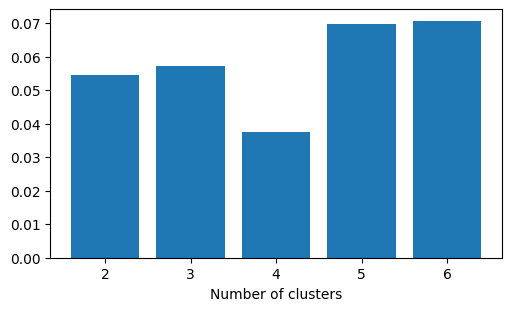

In [30]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
categoriess = df_sil['k']
scores = df_sil['silhouette_score']
ax.bar(categoriess, scores)
ax.set_xlabel('Number of clusters')

#### Identify the Best k

In [31]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS
final_model = KMeans(n_clusters=3, random_state=42, max_iter=1000)
final_model.fit(m_embds)

KMeans(max_iter=1000, n_clusters=3, random_state=42)

In [32]:
labels = final_model.labels_
labels

array([0, 1, 0, 0, 1, 0, 1, 2, 0, 2, 2, 0, 2, 1, 1, 0, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 1, 0, 0, 1, 0, 2, 1, 1, 0, 1, 2,
       2, 2, 0, 2, 2, 2, 1, 2, 0, 0, 1, 2, 0, 2, 2, 0, 2, 0, 2, 0, 1, 0,
       0, 2, 2, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 1, 2, 2, 1, 2, 0, 0, 2, 0,
       1, 2, 0, 2, 0, 2, 1, 1, 1, 1, 2, 1, 0, 1, 0, 2, 1, 1, 0, 0, 2, 0,
       2, 1, 2, 0, 2, 2, 0, 1, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 2, 1, 1, 1,
       1, 2, 1, 2, 1, 2, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 1, 1, 2, 1, 0, 1,
       1, 1, 0, 1, 1, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 2, 0, 0, 2, 1, 0,
       0, 2, 2, 2, 2, 0, 0, 0, 1, 2, 2, 2, 0, 0, 0, 1, 1, 0, 0, 0, 2, 1,
       2, 1, 2, 0, 0, 2, 0, 0, 0, 0, 2, 1, 1, 2, 1, 1, 0, 0, 1, 0, 1, 2,
       2, 1, 2, 0, 2, 2, 0, 2, 2, 1, 2, 1, 0, 1, 2, 2, 1, 2, 0, 1, 2, 1,
       2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 1, 1, 2, 0, 0, 2, 0, 0, 0, 0,
       2, 0, 0, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 1, 2, 1, 1, 0, 1, 1, 2, 2,
       0, 0, 2, 2, 0, 1, 1, 0, 2, 1, 1, 1, 0, 0, 1,

#### Cluster the embeddings using 3 clusters (k=3)

In [ ]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS

#Validar esto

In [33]:
new_df['cluster'] = labels
new_df

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings,cluster
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24T09:03:00Z,https://media.zenfs.com/en/insidermonkey.com/0...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455422844737768, -0.1090475395321846, -0...",0
1,AOS,Here's Why A.O. Smith (AOS) is a Strong Value ...,"Wondering how to pick strong, market-beating s...",2025-07-28T13:40:03Z,https://media.zenfs.com/en/zacks.com/8442d24e1...,Here's Why A.O. Smith (AOS) is a Strong Value ...,"[-0.05186045542359352, -0.04412440210580826, -...",1
2,ABT,Revvity trims 2025 profit forecast as China po...,(Reuters) -Revvity on Monday lowered its full-...,2025-07-28T12:09:43Z,https://media.zenfs.com/en/reuters-finance.com...,Revvity trims 2025 profit forecast as China po...,"[0.00020875422342214733, -0.009514658711850643...",0
3,ABBV,HS market forecast to reach $7.8bn across 7MM ...,This 15.6% CAGR is largely attributed to the l...,2025-07-28T17:09:44Z,https://media.zenfs.com/en/pharmaceutical_tech...,HS market forecast to reach $7.8bn across 7MM ...,"[-0.012529837898910046, -0.025249117985367775,...",0
4,ACN,S&P 500 and Nasdaq 100 Post Record Highs on Tr...,The S&P 500 Index ($SPX ) (SPY ) Monday closed...,2025-07-28T20:34:41Z,https://media.zenfs.com/en/barchart_com_477/ba...,S&P 500 and Nasdaq 100 Post Record Highs on Tr...,"[-0.006708160974085331, -0.047037094831466675,...",1
...,...,...,...,...,...,...,...,...
496,XYL,Aristotle Capital Exited Xylem (XYL) Despite I...,"Aristotle Capital Management, LLC, an investme...",2025-07-23T11:43:34Z,https://media.zenfs.com/en/insidermonkey.com/4...,Aristotle Capital Exited Xylem (XYL) Despite I...,"[0.05527818202972412, -0.06040035933256149, 0....",0
497,YUM,eBay Set to Report Q2 Earnings: What's in Stor...,EBAY's Q2 results are likely to reflect gains ...,2025-07-28T15:13:00Z,https://media.zenfs.com/en/zacks.com/78c587f98...,eBay Set to Report Q2 Earnings: What's in Stor...,"[-0.05692477896809578, 0.07599601149559021, -0...",2
498,ZBRA,Here's What to Expect From Zebra Technologies'...,Zebra Technologies is all set to release its f...,2025-07-16T11:57:00Z,https://media.zenfs.com/en/barchart_com_477/b2...,Here's What to Expect From Zebra Technologies'...,"[-0.13333329558372498, 0.06265336275100708, 0....",2
499,ZBH,Can ISRG's Strong Q2 Procedure Volume Translat...,"ISRG's Q2 procedure growth hits 17%, but conti...",2025-07-25T12:40:00Z,https://media.zenfs.com/en/zacks.com/ffe56c6b4...,Can ISRG's Strong Q2 Procedure Volume Translat...,"[-0.08531150221824646, 0.03004266507923603, -0...",2


### Visualize the 2 first PCA Components of your embeddings

In [34]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS
pca_com=PCA(n_components=2)
pca_com.fit(m_embds)
com=pca_com.components_
com.shape

(2, 384)

In [35]:
matrix_pca = pca_com.transform(m_embds)

In [36]:
matrix_pca

array([[ 0.10060149,  0.0543079 ],
       [ 0.20818116,  0.18518213],
       [-0.02270501, -0.03433285],
       ...,
       [-0.23806445, -0.05542748],
       [-0.19719873, -0.06192316],
       [-0.25351106,  0.06041028]])

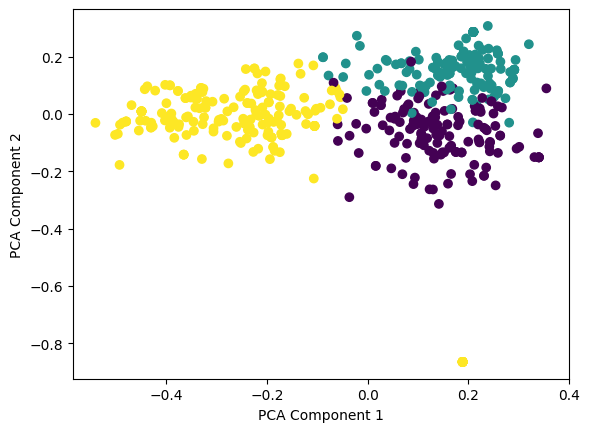

In [37]:
plt.scatter(matrix_pca[:, 0], matrix_pca[:, 1], c=labels)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

#### Analyze the content of each cluster
- Add the kmeans cluster label to your news dataframe
- Print the content of each cluster and analyze it

In [38]:
# YOUR CODE HERE
# USE AS MANY CELLS AS YOU NEED
# MAKE SURE TO DISPLAY INTERMEDIARY RESULS
new_df['label'] = new_df['cluster'].apply(lambda x: f'Cluster {x}')
new_df

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings,cluster,label
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24T09:03:00Z,https://media.zenfs.com/en/insidermonkey.com/0...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455422844737768, -0.1090475395321846, -0...",0,Cluster 0
1,AOS,Here's Why A.O. Smith (AOS) is a Strong Value ...,"Wondering how to pick strong, market-beating s...",2025-07-28T13:40:03Z,https://media.zenfs.com/en/zacks.com/8442d24e1...,Here's Why A.O. Smith (AOS) is a Strong Value ...,"[-0.05186045542359352, -0.04412440210580826, -...",1,Cluster 1
2,ABT,Revvity trims 2025 profit forecast as China po...,(Reuters) -Revvity on Monday lowered its full-...,2025-07-28T12:09:43Z,https://media.zenfs.com/en/reuters-finance.com...,Revvity trims 2025 profit forecast as China po...,"[0.00020875422342214733, -0.009514658711850643...",0,Cluster 0
3,ABBV,HS market forecast to reach $7.8bn across 7MM ...,This 15.6% CAGR is largely attributed to the l...,2025-07-28T17:09:44Z,https://media.zenfs.com/en/pharmaceutical_tech...,HS market forecast to reach $7.8bn across 7MM ...,"[-0.012529837898910046, -0.025249117985367775,...",0,Cluster 0
4,ACN,S&P 500 and Nasdaq 100 Post Record Highs on Tr...,The S&P 500 Index ($SPX ) (SPY ) Monday closed...,2025-07-28T20:34:41Z,https://media.zenfs.com/en/barchart_com_477/ba...,S&P 500 and Nasdaq 100 Post Record Highs on Tr...,"[-0.006708160974085331, -0.047037094831466675,...",1,Cluster 1
...,...,...,...,...,...,...,...,...,...
496,XYL,Aristotle Capital Exited Xylem (XYL) Despite I...,"Aristotle Capital Management, LLC, an investme...",2025-07-23T11:43:34Z,https://media.zenfs.com/en/insidermonkey.com/4...,Aristotle Capital Exited Xylem (XYL) Despite I...,"[0.05527818202972412, -0.06040035933256149, 0....",0,Cluster 0
497,YUM,eBay Set to Report Q2 Earnings: What's in Stor...,EBAY's Q2 results are likely to reflect gains ...,2025-07-28T15:13:00Z,https://media.zenfs.com/en/zacks.com/78c587f98...,eBay Set to Report Q2 Earnings: What's in Stor...,"[-0.05692477896809578, 0.07599601149559021, -0...",2,Cluster 2
498,ZBRA,Here's What to Expect From Zebra Technologies'...,Zebra Technologies is all set to release its f...,2025-07-16T11:57:00Z,https://media.zenfs.com/en/barchart_com_477/b2...,Here's What to Expect From Zebra Technologies'...,"[-0.13333329558372498, 0.06265336275100708, 0....",2,Cluster 2
499,ZBH,Can ISRG's Strong Q2 Procedure Volume Translat...,"ISRG's Q2 procedure growth hits 17%, but conti...",2025-07-25T12:40:00Z,https://media.zenfs.com/en/zacks.com/ffe56c6b4...,Can ISRG's Strong Q2 Procedure Volume Translat...,"[-0.08531150221824646, 0.03004266507923603, -0...",2,Cluster 2


In [39]:
cluster_0 = new_df[new_df['label'] == 'Cluster 0']
cluster_1 = new_df[new_df['label'] == 'Cluster 1']
cluster_2 = new_df[new_df['label'] == 'Cluster 2']

In [40]:
cluster_0

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings,cluster,label
0,MMM,3M Company (MMM): “I Was Surprised” By The Org...,We recently published 12 Stocks Jim Cramer Tal...,2025-07-24T09:03:00Z,https://media.zenfs.com/en/insidermonkey.com/0...,3M Company (MMM): “I Was Surprised” By The Org...,"[0.006455422844737768, -0.1090475395321846, -0...",0,Cluster 0
2,ABT,Revvity trims 2025 profit forecast as China po...,(Reuters) -Revvity on Monday lowered its full-...,2025-07-28T12:09:43Z,https://media.zenfs.com/en/reuters-finance.com...,Revvity trims 2025 profit forecast as China po...,"[0.00020875422342214733, -0.009514658711850643...",0,Cluster 0
3,ABBV,HS market forecast to reach $7.8bn across 7MM ...,This 15.6% CAGR is largely attributed to the l...,2025-07-28T17:09:44Z,https://media.zenfs.com/en/pharmaceutical_tech...,HS market forecast to reach $7.8bn across 7MM ...,"[-0.012529837898910046, -0.025249117985367775,...",0,Cluster 0
5,ADBE,Figma’s Hot IPO Is This Week. Adobe Is Still A...,The software design rivals were ready to merge...,2025-07-28T17:33:00Z,https://finance.yahoo.com/m/06ce6504-08cb-342c...,Figma’s Hot IPO Is This Week. Adobe Is Still A...,"[0.004449496045708656, -0.0640251412987709, 0....",0,Cluster 0
8,AFL,Can ACGL's New Health Suite Boost Growth and E...,Arch Capital launches a flexible supplemental ...,2025-07-28T16:55:00Z,https://media.zenfs.com/en/zacks.com/9d8e6ae4a...,Can ACGL's New Health Suite Boost Growth and E...,"[-0.07831999659538269, 0.012505397200584412, -...",0,Cluster 0
...,...,...,...,...,...,...,...,...,...
487,WST,West Pharmaceutical (WST) Upgraded to Strong B...,West Pharmaceutical (WST) has been upgraded to...,2025-07-28T16:00:02Z,https://media.zenfs.com/en/zacks.com/e8e4b0344...,West Pharmaceutical (WST) Upgraded to Strong B...,"[-0.022659944370388985, -0.06394406408071518, ...",0,Cluster 0
488,WDC,SSD Demand Aids Micron's NAND Growth: Can the ...,Strong demand for SSDs across the client and d...,2025-07-28T13:57:00Z,https://media.zenfs.com/en/zacks.com/f137593ef...,SSD Demand Aids Micron's NAND Growth: Can the ...,"[-0.07612930238246918, -0.048619575798511505, ...",0,Cluster 0
493,WDAY,"Why companies are leaning into skills-first, A...",Moving away from job-centric structures may be...,2025-07-28T10:47:07Z,https://media.zenfs.com/en/fortune_175/2aa0898...,"Why companies are leaning into skills-first, A...","[-0.03127142786979675, -0.09209221601486206, 0...",0,Cluster 0
494,WYNN,Jim Cramer Says He Is “Not a Buyer of Caesar’s...,"Caesars Entertainment, Inc. (NASDAQ:CZR) is on...",2025-07-26T03:31:11Z,https://media.zenfs.com/en/insidermonkey.com/1...,Jim Cramer Says He Is “Not a Buyer of Caesar’s...,"[0.008584938943386078, -0.06618321686983109, -...",0,Cluster 0


In [41]:
cluster_1

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings,cluster,label
1,AOS,Here's Why A.O. Smith (AOS) is a Strong Value ...,"Wondering how to pick strong, market-beating s...",2025-07-28T13:40:03Z,https://media.zenfs.com/en/zacks.com/8442d24e1...,Here's Why A.O. Smith (AOS) is a Strong Value ...,"[-0.05186045542359352, -0.04412440210580826, -...",1,Cluster 1
4,ACN,S&P 500 and Nasdaq 100 Post Record Highs on Tr...,The S&P 500 Index ($SPX ) (SPY ) Monday closed...,2025-07-28T20:34:41Z,https://media.zenfs.com/en/barchart_com_477/ba...,S&P 500 and Nasdaq 100 Post Record Highs on Tr...,"[-0.006708160974085331, -0.047037094831466675,...",1,Cluster 1
6,AMD,"AMD stock jumps on 3 catalysts, Boeing faces p...",Market Catalysts host Julie Hyman tracks today...,2025-07-28T16:15:24Z,https://s.yimg.com/os/creatr-uploaded-images/2...,"AMD stock jumps on 3 catalysts, Boeing faces p...","[0.004821102600544691, -0.04714187979698181, 0...",1,Cluster 1
13,ALB,Albermarle Stock Drops 10%. Lithium Rally Is ‘...,Shares of lithium producer Albemarle fell on M...,2025-07-28T18:03:00Z,https://finance.yahoo.com/m/9ab5e0e0-ea85-3bdd...,Albermarle Stock Drops 10%. Lithium Rally Is ‘...,"[0.03824203833937645, -0.05164828523993492, -0...",1,Cluster 1
14,ARE,2 Reliable Dividend Stocks With Yields Above 5...,This pair of REITs steadily raised their divid...,2025-07-26T09:57:00Z,https://media.zenfs.com/en/motleyfool.com/2bc7...,2 Reliable Dividend Stocks With Yields Above 5...,"[-0.08225090801715851, -0.09000980108976364, -...",1,Cluster 1
...,...,...,...,...,...,...,...,...,...
470,VTRS,GM Is Loading Up on Its Own Shares. Investors ...,General Motors is too darn cheap—and the comp...,2025-07-25T07:00:00Z,https://finance.yahoo.com/m/a70fa920-a21a-326f...,GM Is Loading Up on Its Own Shares. Investors ...,"[0.013798194006085396, -0.07608000189065933, 0...",1,Cluster 1
473,VST,3 No-Brainer Energy Stocks to Buy With $500 Ri...,These three energy companies are riding the AI...,2025-07-28T14:15:00Z,https://media.zenfs.com/en/motleyfool.com/c7bb...,3 No-Brainer Energy Stocks to Buy With $500 Ri...,"[-0.025782262906432152, -0.01239087339490652, ...",1,Cluster 1
484,WEC,Eversource Energy (ES) Expected to Beat Earnin...,Eversource (ES) possesses the right combinatio...,2025-07-24T14:00:04Z,https://media.zenfs.com/en/zacks.com/17a4db66b...,Eversource Energy (ES) Expected to Beat Earnin...,"[-0.04864765331149101, 0.01480407640337944, 0....",1,Cluster 1
489,WY,This is the Most Dangerous Week for Investors ...,This might be the most critical week for inves...,2025-07-28T14:08:45Z,https://media.zenfs.com/en/insidermonkey.com/0...,This is the Most Dangerous Week for Investors ...,"[0.06679262220859528, 0.01036334503442049, 0.0...",1,Cluster 1


In [42]:
cluster_2

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,EMBEDDED_TEXT,Embeddings,cluster,label
7,AES,AES to Report Q2 Earnings: What's in Store for...,AES preps for Q2 earnings with 13.2% projected...,2025-07-28T12:19:00Z,https://media.zenfs.com/en/zacks.com/33f669e8a...,AES to Report Q2 Earnings: What's in Store for...,"[-0.055179446935653687, 0.05670344829559326, -...",2,Cluster 2
9,A,Agilent Technologies' Q3 2025 Earnings: What t...,Agilent Technologies is expected to release it...,2025-07-24T12:27:49Z,https://media.zenfs.com/en/barchart_com_477/ae...,Agilent Technologies' Q3 2025 Earnings: What t...,"[-0.04857131466269493, 0.04065289348363876, -0...",2,Cluster 2
10,APD,NONE,NONE,NONE,NONE,NONE,"[0.0024043370503932238, -0.04070061445236206, ...",2,Cluster 2
12,AKAM,Akamai Technologies Earnings Preview: What to ...,Akamai Technologies is prepared to release its...,2025-07-24T07:55:37Z,https://media.zenfs.com/en/barchart_com_477/a3...,Akamai Technologies Earnings Preview: What to ...,"[-0.057862866669893265, 0.052063245326280594, ...",2,Cluster 2
16,ALLE,Allegion Second Quarter 2025 Earnings: Beats E...,Allegion ( NYSE:ALLE ) Second Quarter 2025 Res...,2025-07-26T12:55:57Z,https://media.zenfs.com/en/simply_wall_st__316...,Allegion Second Quarter 2025 Earnings: Beats E...,"[-0.034476011991500854, -0.00715565076097846, ...",2,Cluster 2
...,...,...,...,...,...,...,...,...,...
495,XEL,Xcel Energy to Release Q2 Earnings: Here's Wha...,XEL's Q2 results may benefit from new customer...,2025-07-25T12:39:00Z,https://media.zenfs.com/en/zacks.com/f8f0217cf...,Xcel Energy to Release Q2 Earnings: Here's Wha...,"[-0.010564113035798073, 0.07664642482995987, -...",2,Cluster 2
497,YUM,eBay Set to Report Q2 Earnings: What's in Stor...,EBAY's Q2 results are likely to reflect gains ...,2025-07-28T15:13:00Z,https://media.zenfs.com/en/zacks.com/78c587f98...,eBay Set to Report Q2 Earnings: What's in Stor...,"[-0.05692477896809578, 0.07599601149559021, -0...",2,Cluster 2
498,ZBRA,Here's What to Expect From Zebra Technologies'...,Zebra Technologies is all set to release its f...,2025-07-16T11:57:00Z,https://media.zenfs.com/en/barchart_com_477/b2...,Here's What to Expect From Zebra Technologies'...,"[-0.13333329558372498, 0.06265336275100708, 0....",2,Cluster 2
499,ZBH,Can ISRG's Strong Q2 Procedure Volume Translat...,"ISRG's Q2 procedure growth hits 17%, but conti...",2025-07-25T12:40:00Z,https://media.zenfs.com/en/zacks.com/ffe56c6b4...,Can ISRG's Strong Q2 Procedure Volume Translat...,"[-0.08531150221824646, 0.03004266507923603, -0...",2,Cluster 2




## Question Section

Take time to reflect on what you've implemented and observed. Answer the following questions in a separate markdown cell or notebook file:

---

### Technical Understanding

#### 1️⃣ How might the choice of embedding model (e.g., MiniLM vs. a larger transformer) affect your clustering results and interpretation?

With a bigger model, the clustering should be more accurate. With the current model, I see that there are some news that could belong ot cluster 2 (cause is about earnnings).

---

#### 2️⃣ What would be the differences in embeddings if you used only the TITLE, only the SUMMARY, or the combination of both? How could you empirically test this?

With the title, the clustering is mixing some news, so that could be litlle complicated, with the summary the model would only be slow but the slilhouete score could be around 0.5 to 0.7 (think so...). But wiht both, the score should be very near to 1, implicating a very good clustering.

---

#### 3️⃣ In what situations would using a different dimensionality reduction method (e.g., t-SNE, UMAP) be preferable over PCA for visualization of embeddings?

WHne you have data that has similar charactericitcs between them, the use of t-SNE or UMAP helps to make a better differentation against PCA. Only if the the objective is to keep the same distance between the points, so the variance will be reduced in the t-SNE and UMAP.


---

### Data Analysis and Interpretation

#### 4️⃣ Based on your cluster analysis, identify at least two potential challenges you faced in interpreting the clusters and propose strategies to address them.

YOUR WRITTEN RESPONSE

---

#### 5️⃣ Did you observe any outliers in your 2D visualization? How would you identify and handle these outliers in a production pipeline?

Yes, for the yellow cluster. What I would do is to scale my data using a RobustScaler before PCA. The RobustScaler is sensitive to the outliers, so the distance will be the same in the origial data and the reduction data.

---

#### 6️⃣ If you could assign a 'label' or 'theme' to each cluster you obtained, what would they be? How confident are you in these assignments, and what could you do to validate them systematically?

For the cluster 2, it should be earnnings, the cluster 1 sotk price, and cluster 0 i think something like politics. When reading the summary and th title, it makes sense for the semantics in the words.

---

### Critical Thinking

#### 7️⃣ If news sentiment was incorporated into the analysis, how might this influence the clustering structure and interpretation of the clusters in a financial analysis context?

I think for buying (positive) or selling (negative) stocks. If we chosose to incorporate it, the clustering should be done by ticker, don´t think that doing it for news will make an impactfull change.

---

#### 8️⃣ Discuss the limitations of using k-means clustering for news embeddings. What alternative clustering methods could address these limitations, and under what conditions would you prefer them?

Whne you have high dimensionality after the reduction of your data, the clustering could be very inneficient.

---

#### 9️⃣ How could the approach in this notebook be extended to analyze the potential impact of news clusters on stock price movements over time? Sketch a high-level pipeline you would implement to test this.

With a sentiment analysis will let us see hte price movements. As before, I think if we took the positive news as a buying signal, then the negative will lead us to sell.
In a pipeline, I should use finbert or other embedding model that could let me have the sentiment anylysis for the last two news. If I see that the sentiment change between the last new and the prevoius one, then I should buy or sell, in case it doesn´t change my position should remain the same unless the stock is stucked.

---

#### 10️⃣ Imagine your clustering shows clear groups of news, but your downstream task (e.g., prediction of stock movement) does not improve. What might explain this disconnect between clear clusters and predictive utility?

I think the most important factor should be that the stock is in a range bound, the second factor to check, is the volatility that the stock is having, and lastly, look for any other pattern in the chart that could lead us to a new movement in the price.

